# Praat-анализ голосового упражнения: учитель vs ученик

Ноутбук поэтапно обрабатывает две записи: эталон учителя и исполнение ученика. На выходе формируется технический отчет, который удобно передавать LLM для генерации педагогического фидбэка.

Что анализируем:
- интонацию и попадание в высоту через F0 + DTW-выравнивание;
- ритм, длительности и атаки звука через onset/intensity-анализ;
- дыхание и поддержку через voiced ratio, паузы, стабильность интенсивности и HNR;
- смыкание голосовых складок через акустические прокси Praat: HNR, jitter, shimmer;
- сходство с правилами упражнения через сравнение с записью учителя.

## 1. Импорты и пути

Если `parselmouth` не установлен, поставь пакет `praat-parselmouth`. Например: `pip install praat-parselmouth librosa scipy matplotlib pandas`.

In [2]:
from pathlib import Path
import hashlib
import json
import os
import warnings

os.environ.setdefault('MPLCONFIGDIR', '/tmp/matplotlib')
os.environ.setdefault('NUMBA_CACHE_DIR', '/tmp/numba_cache')

import librosa
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import parselmouth
from parselmouth.praat import call
from scipy.signal import find_peaks
from scipy.spatial.distance import cdist

warnings.filterwarnings('ignore')

ROOT = Path.cwd().resolve().parent.parent

TEACHER_AUDIO = ROOT / 'datasets/M3/001/teacher/20220330100654.wav'
STUDENT_AUDIO = ROOT / 'datasets/M3/001/student/20220407120212.wav'

OUTPUT_DIR = ROOT / 'PraatAnalysis/reports'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

PITCH_FLOOR = 75
PITCH_CEILING = 600
TIME_STEP = 0.01
REF_HZ = 440.0

print('Teacher:', TEACHER_AUDIO)
print('Student:', STUDENT_AUDIO)
print('Output:', OUTPUT_DIR)


Teacher: /home/evgeniy/Projects/VocalAssistant/datasets/M3/001/teacher/20220330100654.wav
Student: /home/evgeniy/Projects/VocalAssistant/datasets/M3/001/student/20220407120212.wav
Output: /home/evgeniy/Projects/VocalAssistant/PraatAnalysis/reports


## 2. Вспомогательные функции

Здесь лежат безопасные статистики, перевод Hz в cents и небольшие функции для человекочитаемой интерпретации.

In [3]:
def safe_mean(values):
    arr = np.asarray(values, dtype=float)
    arr = arr[np.isfinite(arr)]
    return float(np.mean(arr)) if arr.size else np.nan


def safe_median(values):
    arr = np.asarray(values, dtype=float)
    arr = arr[np.isfinite(arr)]
    return float(np.median(arr)) if arr.size else np.nan


def safe_std(values):
    arr = np.asarray(values, dtype=float)
    arr = arr[np.isfinite(arr)]
    return float(np.std(arr)) if arr.size else np.nan


def safe_percentile(values, q):
    arr = np.asarray(values, dtype=float)
    arr = arr[np.isfinite(arr)]
    return float(np.percentile(arr, q)) if arr.size else np.nan


def fmt(value, digits=2, empty='n/a'):
    if value is None or not np.isfinite(value):
        return empty
    return f'{value:.{digits}f}'


def clamp(value, low=0.0, high=100.0):
    return float(np.clip(value, low, high))


def hz_to_cents(f0, ref=REF_HZ):
    f0 = np.asarray(f0, dtype=float)
    return 1200.0 * np.log2(np.maximum(f0, 1e-6) / ref)


# def severity_from_score(score):
#     if not np.isfinite(score):
#         return 'нет оценки'
#     if score >= 80:
#         return 'хорошо'
#     if score >= 60:
#         return 'умеренные отклонения'
#     if score >= 40:
#         return 'заметные отклонения'
#     return 'критично для упражнения'


def _moving_average(values, window_frames):
    values = np.asarray(values, dtype=float)
    window_frames = int(max(1, window_frames))
    if window_frames <= 1 or values.size == 0:
        return values.copy()
    kernel = np.ones(window_frames, dtype=float) / window_frames
    left = window_frames // 2
    right = window_frames - 1 - left
    padded = np.pad(values, (left, right), mode='edge')
    return np.convolve(padded, kernel, mode='valid')


def estimate_tempo_from_onsets(onsets, min_interval_s=0.18, max_interval_s=8.0):
    onsets = np.asarray(onsets, dtype=float)
    if onsets.size < 2:
        return np.nan
    intervals = np.diff(onsets)
    intervals = intervals[(intervals >= min_interval_s) & (intervals <= max_interval_s)]
    return float(60.0 / np.median(intervals)) if intervals.size else np.nan


def detect_intensity_onsets(
    intensity_time,
    intensity_values,
    min_interval_s=0.4,
    smooth_s=0.04,
    pre_window_s=0.16,
    post_window_s=0.18,
    min_gain_db=5.0,
    min_active_db=None,
):
    """Detect note onsets from robust rises in Praat intensity.

    The detector looks for peaks in positive intensity growth, then keeps only
    candidates with a clear pre/post dB gain and enough absolute intensity.
    """
    t = np.asarray(intensity_time, dtype=float)
    x = np.asarray(intensity_values, dtype=float)
    valid = np.isfinite(t) & np.isfinite(x)
    t = t[valid]
    x = x[valid]
    if t.size < 3:
        return np.array([], dtype=float), np.array([], dtype=float)

    order = np.argsort(t)
    t = t[order]
    x = x[order]
    dt = float(np.median(np.diff(t))) if t.size > 1 else TIME_STEP
    if not np.isfinite(dt) or dt <= 0:
        dt = TIME_STEP

    smooth_frames = max(1, int(round(smooth_s / dt)))
    if smooth_frames % 2 == 0:
        smooth_frames += 1
    x_smooth = _moving_average(x, smooth_frames)

    low = safe_percentile(x_smooth, 10)
    high = safe_percentile(x_smooth, 90)
    dynamic_range = high - low if np.isfinite(high - low) else 0.0
    gain_threshold = max(min_gain_db, min(12.0, 0.22 * dynamic_range))
    active_threshold = min_active_db
    if active_threshold is None:
        active_threshold = low + max(8.0, 0.28 * dynamic_range)

    positive_diff = np.maximum(np.diff(x_smooth, prepend=x_smooth[0]), 0.0)
    novelty = _moving_average(positive_diff, max(1, int(round(0.03 / dt))))
    noise = safe_median(novelty)
    mad = safe_median(np.abs(novelty - noise))
    peak_height = max(noise + 3.0 * mad, safe_percentile(novelty, 75))
    peak_prominence = max(0.08, 3.0 * mad)
    min_distance = max(1, int(round(min_interval_s / dt)))

    peaks, _ = find_peaks(
        novelty,
        height=peak_height,
        prominence=peak_prominence,
        distance=min_distance,
    )

    onsets = []
    pre_frames = max(1, int(round(pre_window_s / dt)))
    post_frames = max(1, int(round(post_window_s / dt)))
    for peak in peaks:
        pre_start = max(0, peak - pre_frames)
        post_end = min(x_smooth.size, peak + post_frames + 1)
        if post_end <= peak or peak <= pre_start:
            continue

        pre_segment = x_smooth[pre_start:peak]
        post_segment = x_smooth[peak:post_end]
        baseline = safe_percentile(pre_segment, 20)
        post_peak = safe_percentile(post_segment, 90)
        if not np.isfinite(baseline) or not np.isfinite(post_peak):
            continue
        if post_peak - baseline < gain_threshold or post_peak < active_threshold:
            continue

        threshold = baseline + 0.25 * (post_peak - baseline)
        local = x_smooth[pre_start:peak + 1]
        above = np.where(local >= threshold)[0]
        onset_idx = pre_start + int(above[0]) if above.size else peak

        if onsets and t[onset_idx] - onsets[-1] < min_interval_s:
            if novelty[onset_idx] > novelty[np.searchsorted(t, onsets[-1])]:
                onsets[-1] = float(t[onset_idx])
            continue
        onsets.append(float(t[onset_idx]))

    return np.asarray(onsets, dtype=float), novelty


## 3. Извлечение признаков Praat

`parselmouth` вызывает алгоритмы Praat: pitch, intensity, harmonicity, formants, jitter, shimmer. Onset/tempo считаются по резким устойчивым подъемам Praat intensity; `librosa` остается для вспомогательных аудио-признаков и спектральной визуализации.


In [4]:
audio_path = TEACHER_AUDIO
audio_path = Path(audio_path)
snd = parselmouth.Sound(str(audio_path))
y, sr = librosa.load(audio_path, sr=None, mono=True)
duration = float(snd.get_total_duration())

pitch = snd.to_pitch(time_step=TIME_STEP, pitch_floor=PITCH_FLOOR, pitch_ceiling=PITCH_CEILING)
time = pitch.xs()
f0 = pitch.selected_array['frequency'].astype(float)
f0[f0 <= 0] = np.nan
voiced_mask = np.isfinite(f0)

In [5]:
intensity = snd.to_intensity(time_step=TIME_STEP, minimum_pitch=PITCH_FLOOR)
intensity_time = intensity.xs()
intensity_values = intensity.values[0].astype(float)
intensity_interp = np.interp(time, intensity_time, intensity_values)

In [6]:
harmonicity = snd.to_harmonicity_cc(time_step=TIME_STEP, minimum_pitch=PITCH_FLOOR)
hnr_time = harmonicity.xs()
hnr_values = harmonicity.values[0].astype(float)
hnr_values[hnr_values <= -200] = np.nan
valid_hnr = np.isfinite(hnr_values)
hnr_interp = np.interp(time, hnr_time[valid_hnr], hnr_values[valid_hnr]) if valid_hnr.sum() >= 2 else np.full_like(time, np.nan)

In [7]:
formant = snd.to_formant_burg(time_step=TIME_STEP)
f1 = np.array([formant.get_value_at_time(1, t) for t in time], dtype=float)
f2 = np.array([formant.get_value_at_time(2, t) for t in time], dtype=float)

In [8]:
onsets, onset_env = detect_intensity_onsets(intensity_time, intensity_values)
tempo = estimate_tempo_from_onsets(onsets)
beat_frames = np.array([], dtype=int)


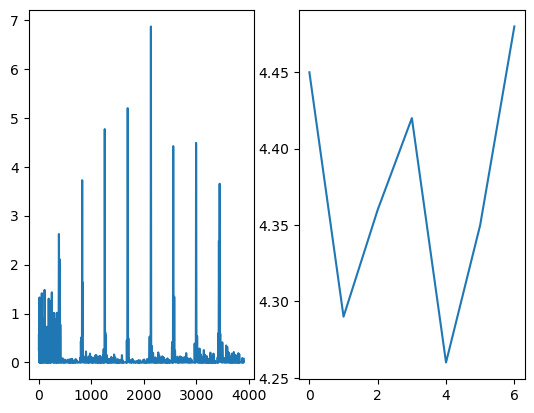

In [9]:
plt.subplot(1, 2, 1)
plt.plot(onset_env)
plt.subplot(1, 2, 2)
plt.plot(np.diff(onsets));

In [10]:
onsets, onset_env = detect_intensity_onsets(intensity_time, intensity_values)
tempo = estimate_tempo_from_onsets(onsets)
beat_frames = np.array([], dtype=int)


(1025, 3912)


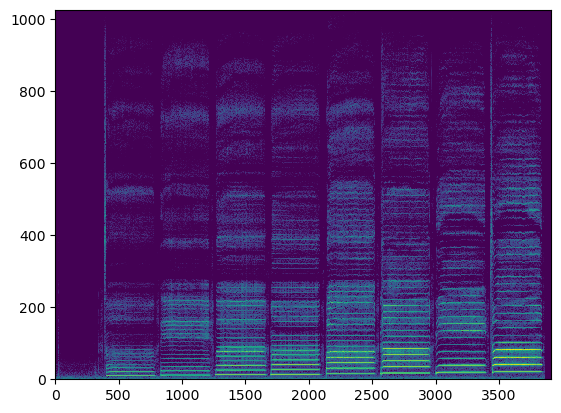

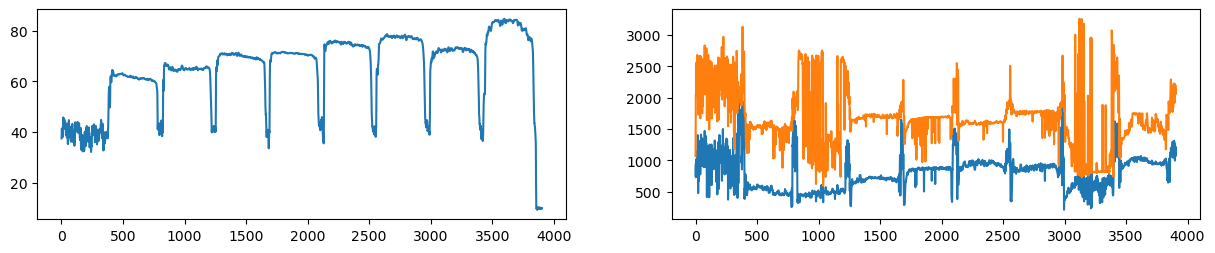

In [11]:
from IPython.display import display, Audio
import matplotlib.pyplot as plt

teacher_logspectrogram = librosa.amplitude_to_db(np.abs(librosa.stft(y, hop_length=int(TIME_STEP * sr))))
print(teacher_logspectrogram.shape)
plt.pcolormesh(teacher_logspectrogram)
display(Audio(y, rate=sr))
plt.figure(figsize=(15, 6))
plt.subplot(2, 2, 1)
plt.plot(np.arange(len(intensity_values)), intensity_values)
plt.subplot(2, 2, 2)
plt.plot(np.arange(len(f1)), f1)
plt.plot(np.arange(len(f2)), f2);

In [12]:
def extract_praat_features(audio_path: str, time_step: float = TIME_STEP):
    audio_path = Path(audio_path)
    snd = parselmouth.Sound(str(audio_path))
    y, sr = librosa.load(audio_path, sr=None, mono=True)
    duration = float(snd.get_total_duration())

    # Extract F0 / Pitch
    pitch = snd.to_pitch(time_step=time_step, pitch_floor=PITCH_FLOOR, pitch_ceiling=PITCH_CEILING)
    time = pitch.xs()
    f0 = pitch.selected_array['frequency'].astype(float)
    f0[f0 <= 0] = np.nan
    voiced_mask = np.isfinite(f0)

    # Extract Energy / Intensity (dB)
    intensity = snd.to_intensity(time_step=time_step, minimum_pitch=PITCH_FLOOR)
    intensity_time = intensity.xs()
    intensity_values = intensity.values[0].astype(float)
    intensity_interp = np.interp(time, intensity_time, intensity_values)

    # Doing correlation analysis (Vocal folds indirect analysis)
    harmonicity = snd.to_harmonicity_cc(time_step=time_step, minimum_pitch=PITCH_FLOOR)
    hnr_time = harmonicity.xs()
    hnr_values = harmonicity.values[0].astype(float)
    hnr_values[hnr_values <= -200] = np.nan
    valid_hnr = np.isfinite(hnr_values)
    hnr_interp = np.interp(time, hnr_time[valid_hnr], hnr_values[valid_hnr]) if valid_hnr.sum() >= 2 else np.full_like(time, np.nan)

    # Extract F1, F2 formants
    formant = snd.to_formant_burg(time_step=time_step)
    f1 = np.array([formant.get_value_at_time(1, t) for t in time], dtype=float)
    f2 = np.array([formant.get_value_at_time(2, t) for t in time], dtype=float)

    # Jitter / Shimmer
    point_process = call(snd, 'To PointProcess (periodic, cc)', PITCH_FLOOR, PITCH_CEILING)
    jitter_local = call(point_process, 'Get jitter (local)', 0, 0, 0.0001, 0.02, 1.3)
    shimmer_local = call([snd, point_process], 'Get shimmer (local)', 0, 0, 0.0001, 0.02, 1.3, 1.6)

    # Onset Detection / Tempo from robust Praat intensity rises
    onsets, onset_env = detect_intensity_onsets(intensity_time, intensity_values)
    tempo = estimate_tempo_from_onsets(onsets)

    # Extract Energy (low level feature)
    rms = librosa.feature.rms(y=y)[0]
    rms_time = librosa.frames_to_time(np.arange(len(rms)), sr=sr)
    rms_interp = np.interp(time, rms_time, rms)

    silent_gaps = []
    if len(time) > 1:
        unvoiced = ~voiced_mask
        start = None
        for idx, is_unvoiced in enumerate(unvoiced):
            if is_unvoiced and start is None:
                start = idx
            if (not is_unvoiced or idx == len(unvoiced) - 1) and start is not None:
                end = idx if not is_unvoiced else idx + 1
                gap = time[min(end - 1, len(time) - 1)] - time[start]
                if gap >= 0.15:
                    silent_gaps.append(float(gap))
                start = None

    return {
        'path': str(audio_path),
        'sr': sr,
        'duration': duration,
        'time': time,
        'f0': f0,
        'voiced_mask': voiced_mask,
        'voiced_ratio': float(np.mean(voiced_mask)) if voiced_mask.size else np.nan,
        'intensity': intensity_interp,
        'hnr': hnr_interp,
        'f1': f1,
        'f2': f2,
        'jitter': float(jitter_local),
        'shimmer': float(shimmer_local),
        'onsets': onsets,
        'onset_env': onset_env,
        'tempo': tempo,
        'rms': rms_interp,
        'silent_gaps': np.array(silent_gaps, dtype=float),
    }


teacher = extract_praat_features(TEACHER_AUDIO)
student = extract_praat_features(STUDENT_AUDIO)

pd.DataFrame([
    {'role': 'teacher', 'duration_s': teacher['duration'], 'tempo_bpm': teacher['tempo'], 'voiced_ratio': teacher['voiced_ratio'], 'jitter': teacher['jitter'], 'shimmer': teacher['shimmer'], 'hnr_mean_db': safe_mean(teacher['hnr']), 'onsets': len(teacher['onsets'])},
    {'role': 'student', 'duration_s': student['duration'], 'tempo_bpm': student['tempo'], 'voiced_ratio': student['voiced_ratio'], 'jitter': student['jitter'], 'shimmer': student['shimmer'], 'hnr_mean_db': safe_mean(student['hnr']), 'onsets': len(student['onsets'])},
])


,role,duration_s,tempo_bpm,voiced_ratio,jitter,shimmer,hnr_mean_db,onsets
0,teacher,39.118005,13.761468,0.798618,0.002367,0.016138,23.976930,8
1,student,39.456916,13.856813,0.768899,0.002112,0.014800,22.053703,8


## 4. Визуальная проверка извлеченных контуров

Перед автоматическими выводами полезно посмотреть, не сломались ли pitch/intensity/onset-контуры из-за шума, тишины или неподходящих `PITCH_FLOOR/PITCH_CEILING`.

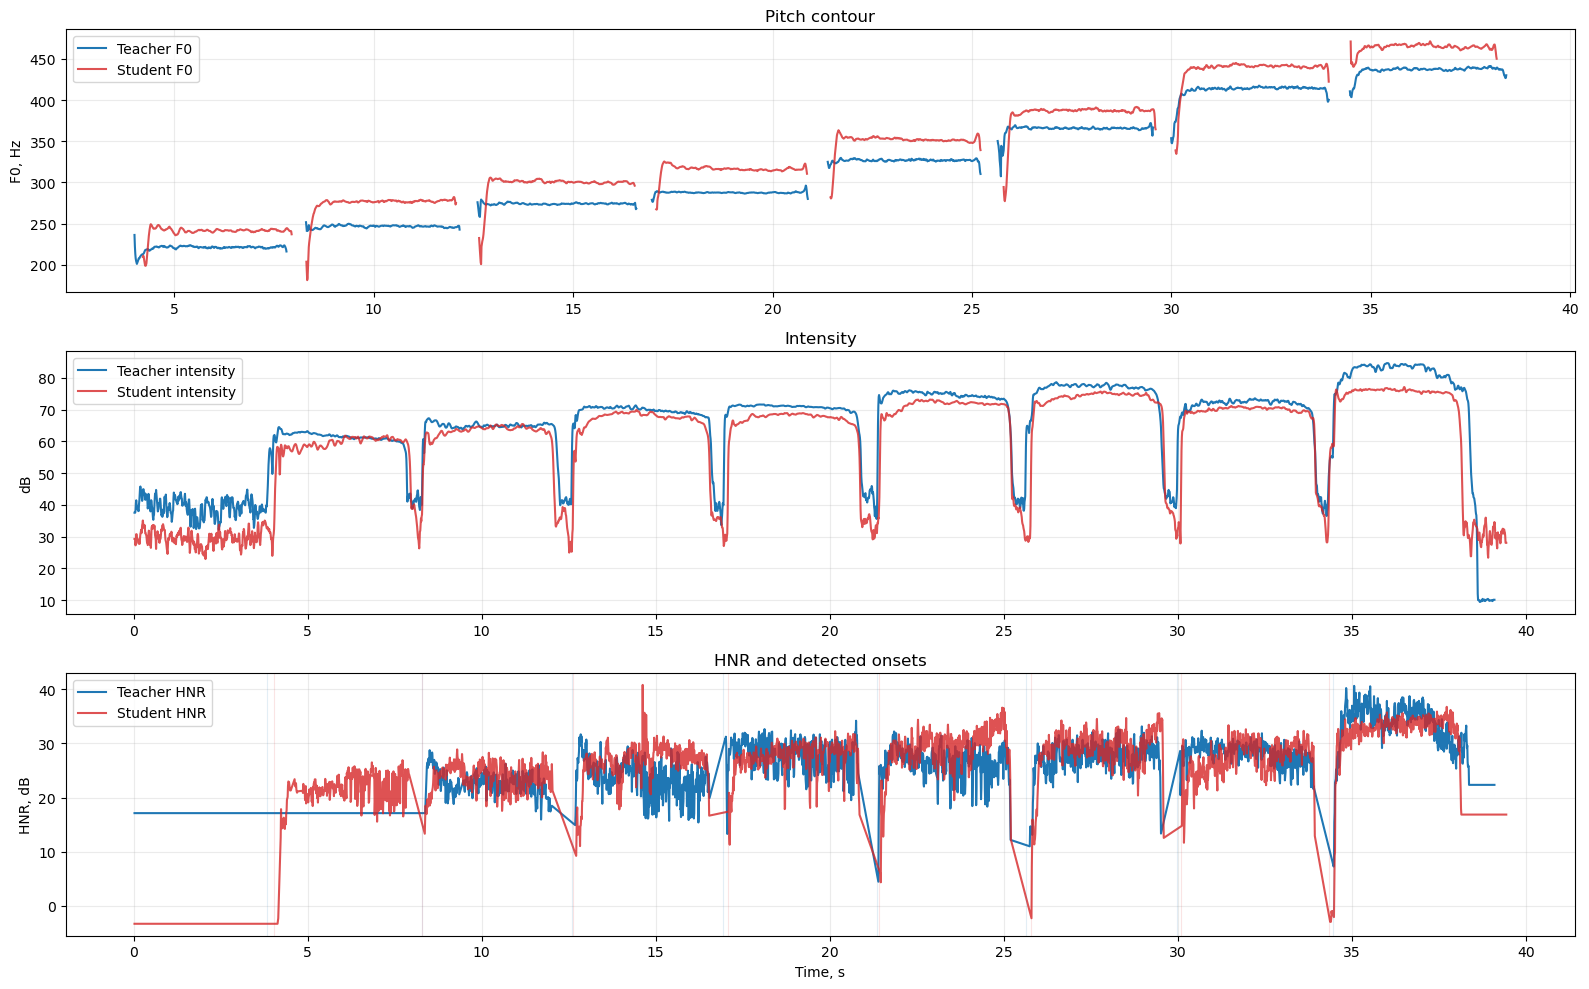

In [13]:
fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=False)

axes[0].plot(teacher['time'], teacher['f0'], label='Teacher F0', color='tab:blue')
axes[0].plot(student['time'], student['f0'], label='Student F0', color='tab:red', alpha=0.8)
axes[0].set_title('Pitch contour')
axes[0].set_ylabel('F0, Hz')
axes[0].grid(alpha=0.25)
axes[0].legend()

axes[1].plot(teacher['time'], teacher['intensity'], label='Teacher intensity', color='tab:blue')
axes[1].plot(student['time'], student['intensity'], label='Student intensity', color='tab:red', alpha=0.8)
axes[1].set_title('Intensity')
axes[1].set_ylabel('dB')
axes[1].grid(alpha=0.25)
axes[1].legend()

axes[2].plot(teacher['time'], teacher['hnr'], label='Teacher HNR', color='tab:blue')
axes[2].plot(student['time'], student['hnr'], label='Student HNR', color='tab:red', alpha=0.8)
for onset in teacher['onsets'][:50]:
    axes[2].axvline(onset, color='tab:blue', alpha=0.12, linewidth=0.8)
for onset in student['onsets'][:50]:
    axes[2].axvline(onset, color='tab:red', alpha=0.12, linewidth=0.8)
axes[2].set_title('HNR and detected onsets')
axes[2].set_xlabel('Time, s')
axes[2].set_ylabel('HNR, dB')
axes[2].grid(alpha=0.25)
axes[2].legend()

plt.tight_layout()

## 5. Сравнение с эталоном: DTW, интонация, ритм, атака

DTW выравнивает два исполнения по pitch-контуру. Это позволяет сравнивать записи даже если ученик немного ускоряется или замедляется.

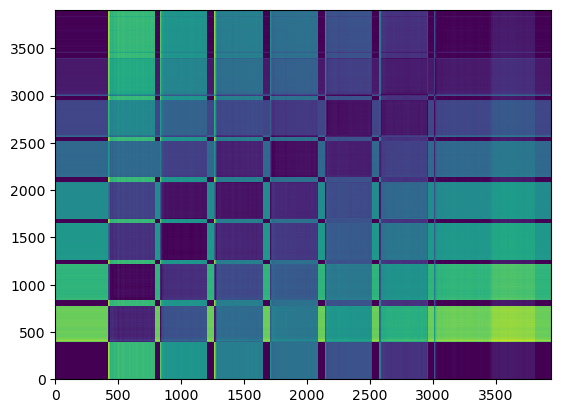

In [14]:
teacher_cents = hz_to_cents(teacher['f0'])
student_cents = hz_to_cents(student['f0'])
teacher_seq = np.nan_to_num(teacher_cents, nan=0.0).reshape(1, -1)
student_seq = np.nan_to_num(student_cents, nan=0.0).reshape(1, -1)

cost = cdist(teacher_seq.T, student_seq.T, metric='euclidean')
plt.pcolormesh(cost);

(6858, 2) (3908, 3942)


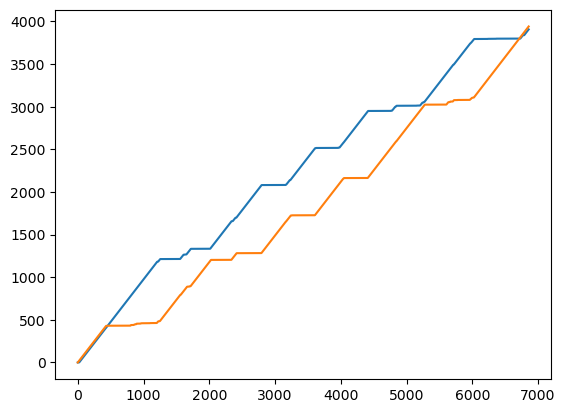

In [15]:
acc_cost, wp = librosa.sequence.dtw(C=cost)
path = wp[::-1]

t_idx = []
s_idx = []
errors = []
for i, j in path:
    tf = teacher['f0'][i]
    sf = student['f0'][j]
    if np.isfinite(tf) and np.isfinite(sf) and tf > 0 and sf > 0:
        t_idx.append(i)
        s_idx.append(j)
        errors.append(float(hz_to_cents(sf) - hz_to_cents(tf)))

plt.plot(path)
print(path.shape, cost.shape)

In [16]:
def align_by_pitch(teacher, student):
    teacher_cents = hz_to_cents(teacher['f0'])
    student_cents = hz_to_cents(student['f0'])
    teacher_seq = np.nan_to_num(teacher_cents, nan=0.0).reshape(1, -1)
    student_seq = np.nan_to_num(student_cents, nan=0.0).reshape(1, -1)

    cost = cdist(teacher_seq.T, student_seq.T, metric='euclidean')
    _, wp = librosa.sequence.dtw(C=cost)
    path = wp[::-1]

    t_idx = []
    s_idx = []
    errors = []
    for i, j in path:
        tf = teacher['f0'][i]
        sf = student['f0'][j]
        if np.isfinite(tf) and np.isfinite(sf) and tf > 0 and sf > 0:
            t_idx.append(i)
            s_idx.append(j)
            errors.append(float(hz_to_cents(sf) - hz_to_cents(tf)))

    return {
        'path': path,
        'teacher_idx': np.array(t_idx, dtype=int),
        'student_idx': np.array(s_idx, dtype=int),
        'pitch_errors_cents': np.array(errors, dtype=float),
    }


def compare_onsets(teacher_onsets, student_onsets):
    n = min(len(teacher_onsets), len(student_onsets))
    if n == 0:
        return np.array([])
    return np.asarray(student_onsets[:n]) - np.asarray(teacher_onsets[:n])


def compare_durations(teacher_onsets, student_onsets):
    n = min(len(teacher_onsets), len(student_onsets))
    if n < 2:
        return np.array([])
    return np.diff(student_onsets[:n]) - np.diff(teacher_onsets[:n])


def attack_metrics(features, window_sec=0.18):
    """
    Для каждой обнаруженной атаки:

    Берёт базовую громкость до атаки (pre): интервал от 50 мс до начала ноты.
    Вычисляет base как медиану интенсивности (дБ) в этом окне — это уровень «тишины» или фона прямо перед нотой.

    Берёт окно после атаки (post): длительностью window_sec (по умолчанию 180 мс).
    Находит peak — 90-й процентиль интенсивности в этом окне (почти максимум, но устойчив к выбросам).

    Определяет целевой уровень (target):
    base + 0.8 * (peak - base) — это 80% от полного прироста громкости от фона до пика.

    Ищет момент, когда интенсивность впервые достигает или превышает target.
    rise_time — время от onset до этого момента (в секундах).

    Вычисляет attack_gain_db = peak - base — полный прирост громкости в децибелах.

    Результат — таблица с колонками:

    onset_s — время атаки (с)

    attack_gain_db — общий динамический диапазон атаки (дБ)

    attack_rise_time_s — время нарастания до 80% от полного прироста (с)
    """
    
    time = features['time']
    intensity = features['intensity']
    rows = []
    for onset in features['onsets']:
        pre = (time >= onset - 0.05) & (time < onset)
        post = (time >= onset) & (time <= onset + window_sec)
        if pre.sum() < 2 or post.sum() < 3:
            continue
        base = safe_median(intensity[pre])
        peak = safe_percentile(intensity[post], 90)
        target = base + 0.8 * (peak - base)
        post_time = time[post]
        post_intensity = intensity[post]
        reached = np.where(post_intensity >= target)[0]
        rise_time = float(post_time[reached[0]] - onset) if reached.size else np.nan
        rows.append({'onset_s': float(onset), 'attack_gain_db': peak - base, 'attack_rise_time_s': rise_time})
    return pd.DataFrame(rows)


def vibrato_metrics(f0, time):
    valid = np.isfinite(f0)
    if valid.sum() < 10 or len(time) < 2:
        return {'rate_hz': np.nan, 'extent_hz': np.nan}
    frame_rate = 1.0 / np.median(np.diff(time))
    f0_clean = np.nan_to_num(f0, nan=safe_median(f0))
    peaks, _ = find_peaks(f0_clean, distance=max(1, int(frame_rate / 12)))
    if len(peaks) < 2:
        return {'rate_hz': np.nan, 'extent_hz': safe_std(f0[valid])}
    peak_times = time[peaks]
    periods = np.diff(peak_times)
    periods = periods[periods > 0]
    return {'rate_hz': float(1.0 / np.mean(periods)) if periods.size else np.nan, 'extent_hz': safe_std(f0[valid])}


alignment = align_by_pitch(teacher, student)
onset_errors = compare_onsets(teacher['onsets'], student['onsets'])
duration_errors = compare_durations(teacher['onsets'], student['onsets'])
teacher_attacks = attack_metrics(teacher)
student_attacks = attack_metrics(student)
teacher_vibrato = vibrato_metrics(teacher['f0'], teacher['time'])
student_vibrato = vibrato_metrics(student['f0'], student['time'])

print('Aligned voiced frames:', len(alignment['pitch_errors_cents']))
print('Teacher attacks:', len(teacher_attacks), '| Student attacks:', len(student_attacks))

Aligned voiced frames: 5837
Teacher attacks: 8 | Student attacks: 8


## 6. Метрики и эвристические оценки

In [17]:
def evaluate(teacher, student, alignment, onset_errors, duration_errors, teacher_attacks, student_attacks):
    pitch_errors = alignment['pitch_errors_cents']
    abs_pitch = np.abs(pitch_errors)

    onset_mae = safe_mean(np.abs(onset_errors))
    duration_mae = safe_mean(np.abs(duration_errors))
    tempo_diff = abs(student['tempo'] - teacher['tempo'])
    hnr_teacher = safe_mean(teacher['hnr'])
    hnr_student = safe_mean(student['hnr'])
    hnr_diff = hnr_student - hnr_teacher
    voiced_ratio_diff = student['voiced_ratio'] - teacher['voiced_ratio']

    attack_rise_teacher = safe_median(teacher_attacks['attack_rise_time_s']) if not teacher_attacks.empty else np.nan
    attack_rise_student = safe_median(student_attacks['attack_rise_time_s']) if not student_attacks.empty else np.nan
    attack_gain_teacher = safe_median(teacher_attacks['attack_gain_db']) if not teacher_attacks.empty else np.nan
    attack_gain_student = safe_median(student_attacks['attack_gain_db']) if not student_attacks.empty else np.nan

    intonation_score = clamp(100.0 - safe_mean(abs_pitch) / 1.5)
    rhythm_score = clamp(np.nanmean([
        100.0 - onset_mae * 1000.0 / 5.0 if np.isfinite(onset_mae) else np.nan,
        100.0 - duration_mae * 1000.0 / 7.0 if np.isfinite(duration_mae) else np.nan,
        100.0 - tempo_diff * 2.0 if np.isfinite(tempo_diff) else np.nan,
    ]))
    voice_score = clamp(np.nanmean([
        100.0 - abs(voiced_ratio_diff) * 250.0 if np.isfinite(voiced_ratio_diff) else np.nan,
        100.0 - abs(student['jitter'] - teacher['jitter']) * 6000.0,
        100.0 - abs(student['shimmer'] - teacher['shimmer']) * 900.0,
        100.0 - abs(hnr_diff) * 2.0 if np.isfinite(hnr_diff) else np.nan,
    ]))
    attack_score = clamp(np.nanmean([
        100.0 - abs(attack_rise_student - attack_rise_teacher) * 1000.0 / 3.0 if np.isfinite(attack_rise_student) and np.isfinite(attack_rise_teacher) else np.nan,
        100.0 - abs(attack_gain_student - attack_gain_teacher) * 8.0 if np.isfinite(attack_gain_student) and np.isfinite(attack_gain_teacher) else np.nan,
    ]))
    breath_score = clamp(np.nanmean([
        100.0 - abs(voiced_ratio_diff) * 250.0 if np.isfinite(voiced_ratio_diff) else np.nan,
        100.0 - abs(safe_mean(student['silent_gaps']) - safe_mean(teacher['silent_gaps'])) * 100.0 if np.isfinite(safe_mean(student['silent_gaps'])) and np.isfinite(safe_mean(teacher['silent_gaps'])) else np.nan,
        100.0 - max(0.0, -hnr_diff) * 4.0 if np.isfinite(hnr_diff) else np.nan,
    ]))

    return {
        'intonation_score': intonation_score,
        'rhythm_score': rhythm_score,
        'voice_closure_score': voice_score,
        'attack_score': attack_score,
        'breath_score': breath_score,
        'pitch_mean_abs_cents': safe_mean(abs_pitch),
        'pitch_median_abs_cents': safe_median(abs_pitch),
        'pitch_bias_cents': safe_mean(pitch_errors),
        'pitch_std_cents': safe_std(pitch_errors),
        'in_tune_100_percent': 100.0 * np.mean(abs_pitch <= 100) if abs_pitch.size else np.nan,
        'onset_mae_ms': onset_mae * 1000.0 if np.isfinite(onset_mae) else np.nan,
        'duration_mae_ms': duration_mae * 1000.0 if np.isfinite(duration_mae) else np.nan,
        'tempo_diff_bpm': tempo_diff,
        'voiced_ratio_diff': voiced_ratio_diff,
        'hnr_teacher_db': hnr_teacher,
        'hnr_student_db': hnr_student,
        'hnr_diff_db': hnr_diff,
        'jitter_teacher': teacher['jitter'],
        'jitter_student': student['jitter'],
        'shimmer_teacher': teacher['shimmer'],
        'shimmer_student': student['shimmer'],
        'attack_rise_teacher_ms': attack_rise_teacher * 1000.0 if np.isfinite(attack_rise_teacher) else np.nan,
        'attack_rise_student_ms': attack_rise_student * 1000.0 if np.isfinite(attack_rise_student) else np.nan,
        'attack_gain_teacher_db': attack_gain_teacher,
        'attack_gain_student_db': attack_gain_student,
        'vibrato_rate_teacher_hz': teacher_vibrato['rate_hz'],
        'vibrato_rate_student_hz': student_vibrato['rate_hz'],
        'vibrato_extent_teacher_hz': teacher_vibrato['extent_hz'],
        'vibrato_extent_student_hz': student_vibrato['extent_hz'],
        'teacher_silent_gaps_count': int(len(teacher['silent_gaps'])),
        'student_silent_gaps_count': int(len(student['silent_gaps'])),
        'teacher_silent_gap_mean_s': safe_mean(teacher['silent_gaps']),
        'student_silent_gap_mean_s': safe_mean(student['silent_gaps']),
    }


metrics = evaluate(teacher, student, alignment, onset_errors, duration_errors, teacher_attacks, student_attacks)
pd.DataFrame([metrics]).T.rename(columns={0: 'value'})

,value
intonation_score,87.216368
rhythm_score,88.034509
voice_closure_score,96.497152
attack_score,64.996080
breath_score,90.292432
pitch_mean_abs_cents,19.175447
pitch_median_abs_cents,8.624600
pitch_bias_cents,2.967788
pitch_std_cents,44.261018
in_tune_100_percent,97.824225


## 7. Диагностические графики

Эти графики не обязательно передавать LLM, но они помогают быстро проверить, почему отчет получился именно таким.

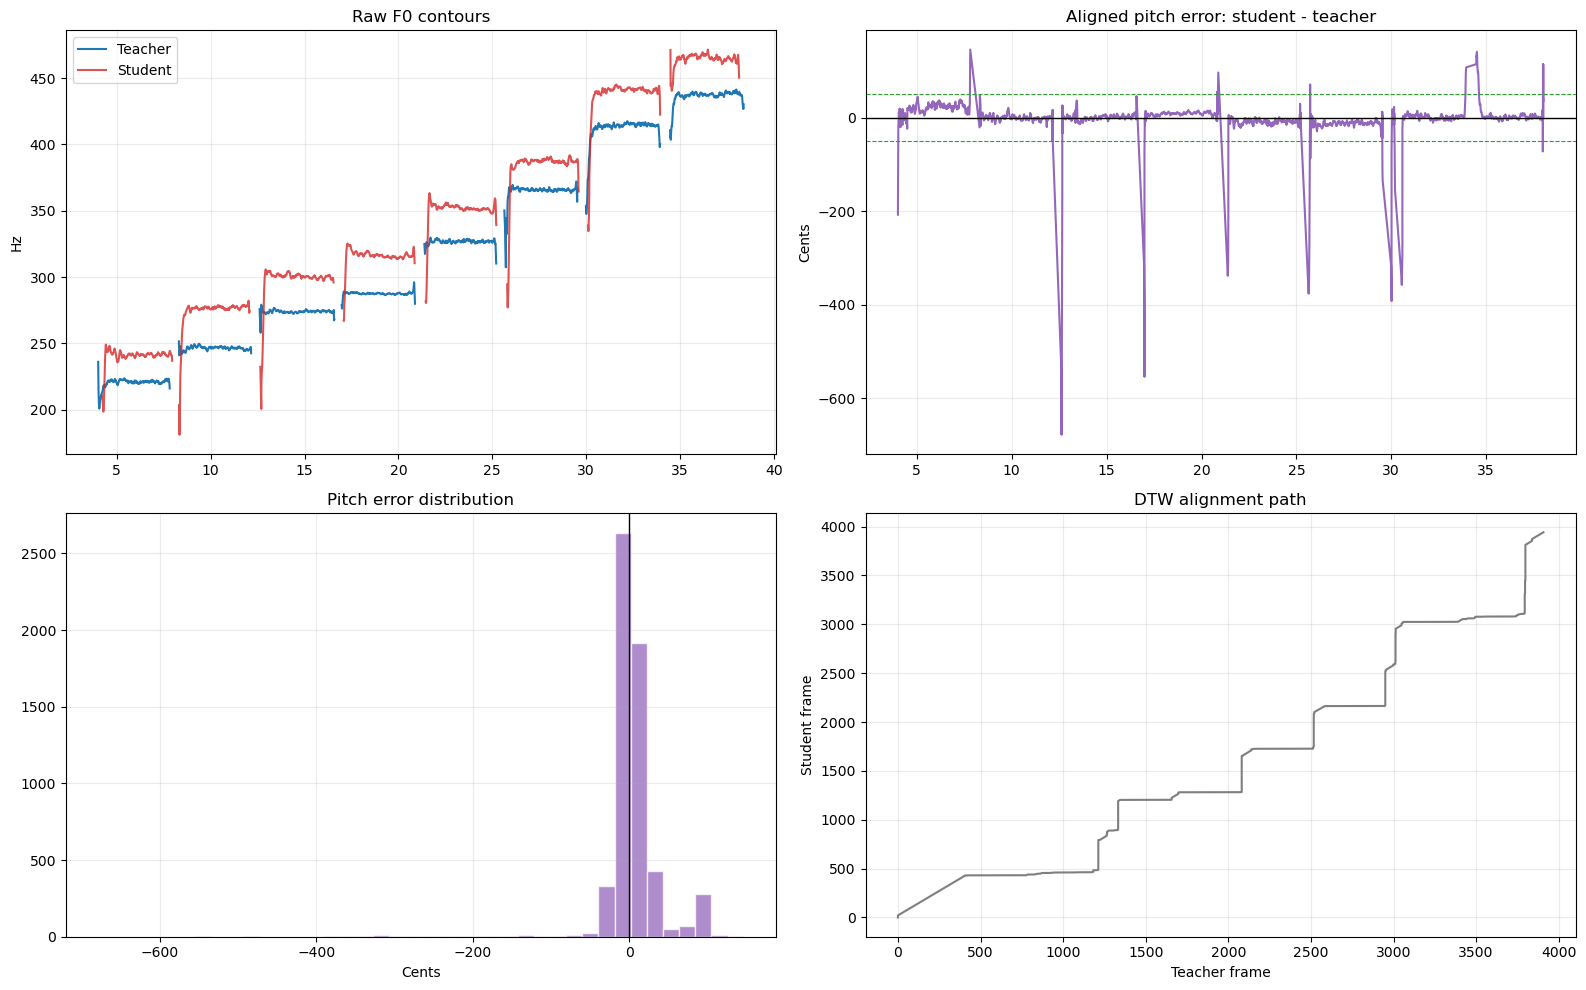

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

axes[0, 0].plot(teacher['time'], teacher['f0'], color='tab:blue', label='Teacher')
axes[0, 0].plot(student['time'], student['f0'], color='tab:red', alpha=0.8, label='Student')
axes[0, 0].set_title('Raw F0 contours')
axes[0, 0].set_ylabel('Hz')
axes[0, 0].grid(alpha=0.25)
axes[0, 0].legend()

errors = alignment['pitch_errors_cents']
if len(errors):
    axes[0, 1].plot(teacher['time'][alignment['teacher_idx']], errors, color='tab:purple')
    axes[0, 1].axhline(0, color='black', linewidth=1)
    axes[0, 1].axhline(50, color='tab:green', linestyle='--', linewidth=0.8)
    axes[0, 1].axhline(-50, color='tab:green', linestyle='--', linewidth=0.8)
axes[0, 1].set_title('Aligned pitch error: student - teacher')
axes[0, 1].set_ylabel('Cents')
axes[0, 1].grid(alpha=0.25)

if len(errors):
    axes[1, 0].hist(errors, bins=40, color='tab:purple', alpha=0.75, edgecolor='white')
    axes[1, 0].axvline(0, color='black', linewidth=1)
axes[1, 0].set_title('Pitch error distribution')
axes[1, 0].set_xlabel('Cents')
axes[1, 0].grid(alpha=0.25)

if len(alignment['path']):
    path = np.asarray(alignment['path'])
    axes[1, 1].plot(path[:, 0], path[:, 1], color='tab:gray')
axes[1, 1].set_title('DTW alignment path')
axes[1, 1].set_xlabel('Teacher frame')
axes[1, 1].set_ylabel('Student frame')
axes[1, 1].grid(alpha=0.25)

plt.tight_layout()

## 8. Формирование отчета для LLM

Отчет специально написан как промежуточный технический слой: без красивой педагогической упаковки, но с конкретными выводами и приоритетами.

In [19]:
def build_recommendation_flags(metrics):
    flags = []
    if np.isfinite(metrics['pitch_mean_abs_cents']) and metrics['pitch_mean_abs_cents'] > 50:
        direction = 'выше эталона' if metrics['pitch_bias_cents'] > 0 else 'ниже эталона'
        flags.append(f'Интонация: средняя ошибка {fmt(metrics["pitch_mean_abs_cents"], 1)} cents, общий сдвиг {direction}.')
    if np.isfinite(metrics['onset_mae_ms']) and metrics['onset_mae_ms'] > 120:
        flags.append(f'Ритм/вступления: среднее расхождение атак {fmt(metrics["onset_mae_ms"], 0)} ms; ученику нужно точнее попадать во входы.')
    if np.isfinite(metrics['duration_mae_ms']) and metrics['duration_mae_ms'] > 150:
        flags.append(f'Длительности: среднее расхождение {fmt(metrics["duration_mae_ms"], 0)} ms; ноты удерживаются не как в эталоне.')
    if np.isfinite(metrics['attack_score']) and metrics['attack_score'] < 70:
        flags.append('Атака звука: характер начала нот отличается от учителя; проверить мягкость/резкость входа и синхронность начала фонации.')
    if np.isfinite(metrics['breath_score']) and metrics['breath_score'] < 70:
        flags.append('Дыхание/поддержка: есть признаки отличия в паузах, доле озвученного сигнала или стабильности HNR.')
    if np.isfinite(metrics['hnr_diff_db']) and metrics['hnr_diff_db'] < -2:
        flags.append('Смыкание/шумность: HNR ученика заметно ниже эталона, возможно больше придыхания или менее плотное смыкание.')
    if abs(metrics['shimmer_student'] - metrics['shimmer_teacher']) > 0.01:
        flags.append('Стабильность амплитуды: shimmer отличается от эталона; возможна нестабильная подача или давление воздуха.')
    if abs(metrics['jitter_student'] - metrics['jitter_teacher']) > 0.005:
        flags.append('Стабильность периода: jitter отличается от эталона; возможна нестабильность фонации.')
    return flags


def make_llm_report(teacher_path, student_path, teacher, student, metrics):
    flags = build_recommendation_flags(metrics)
    lines = []
    lines.append('===== ТЕХНИЧЕСКИЙ ОТЧЕТ ДЛЯ LLM: АНАЛИЗ ГОЛОСОВОГО УПРАЖНЕНИЯ =====')
    lines.append('----- Аудио -----')
    lines.append(f'Учитель: {teacher_path}')
    lines.append(f'Ученик: {student_path}')
    lines.append(f'Длительность: учитель {fmt(teacher["duration"], 2)} s | ученик {fmt(student["duration"], 2)} s')
    lines.append(f'Tempo: учитель {fmt(teacher["tempo"], 1)} BPM | ученик {fmt(student["tempo"], 1)} BPM | diff {fmt(metrics["tempo_diff_bpm"], 1)} BPM')
    lines.append('')
    lines.append('----- Сводная оценка выполнения правила упражнения -----')
    # lines.append(f'Overall: {fmt(metrics["overall_score"], 1)}/100')# ({severity_from_score(metrics["overall_score"])})')
    lines.append(f'Интонация: {fmt(metrics["intonation_score"], 1)}/100')# ({severity_from_score(metrics["intonation_score"])})')
    lines.append(f'Ритм: {fmt(metrics["rhythm_score"], 1)}/100')# ({severity_from_score(metrics["rhythm_score"])})')
    lines.append(f'Атака звука: {fmt(metrics["attack_score"], 1)}/100')# ({severity_from_score(metrics["attack_score"])})')
    lines.append(f'Дыхание/поддержка: {fmt(metrics["breath_score"], 1)}/100')# ({severity_from_score(metrics["breath_score"])})')
    lines.append(f'Смыкание/голосовой контроль: {fmt(metrics["voice_closure_score"], 1)}/100')# ({severity_from_score(metrics["voice_closure_score"])})')
    lines.append('')
    lines.append('----- Интонация -----')
    lines.append(f'Aligned voiced frames: {len(alignment["pitch_errors_cents"])}')
    lines.append(f'Mean absolute pitch error: {fmt(metrics["pitch_mean_abs_cents"], 1)} cents')
    lines.append(f'Median absolute pitch error: {fmt(metrics["pitch_median_abs_cents"], 1)} cents')
    lines.append(f'Pitch bias student-teacher: {fmt(metrics["pitch_bias_cents"], 1)} cents')
    lines.append(f'Pitch spread std: {fmt(metrics["pitch_std_cents"], 1)} cents')
    # lines.append(f'P90 absolute pitch error: {fmt(metrics["pitch_p90_abs_cents"], 1)} cents')
    lines.append('')
    lines.append('----- Ритм и длительности -----')
    lines.append(f'Onsets detected: teacher {len(teacher["onsets"])} | student {len(student["onsets"])}')
    lines.append(f'Onset MAE: {fmt(metrics["onset_mae_ms"], 1)} ms')
    lines.append(f'Duration MAE: {fmt(metrics["duration_mae_ms"], 1)} ms')
    lines.append('')
    lines.append('----- Атака звука -----')
    lines.append('Метрика атаки основана на скорости роста intensity после detected onset.')
    lines.append(f'Median attack rise time: teacher {fmt(metrics["attack_rise_teacher_ms"], 1)} ms | student {fmt(metrics["attack_rise_student_ms"], 1)} ms')
    lines.append(f'Median attack gain: teacher {fmt(metrics["attack_gain_teacher_db"], 2)} dB | student {fmt(metrics["attack_gain_student_db"], 2)} dB')
    lines.append('')
    lines.append('----- Дыхание и поддержка -----')
    lines.append('Прокси: voiced ratio, длинные неозвученные паузы, HNR и стабильность интенсивности.')
    lines.append(f'Voiced ratio: teacher {fmt(teacher["voiced_ratio"], 3)} | student {fmt(student["voiced_ratio"], 3)} | diff {fmt(metrics["voiced_ratio_diff"], 3)}')
    lines.append(f'Silent gaps >=150 ms: teacher {metrics["teacher_silent_gaps_count"]} | student {metrics["student_silent_gaps_count"]}')
    lines.append(f'Mean silent gap: teacher {fmt(metrics["teacher_silent_gap_mean_s"], 2)} s | student {fmt(metrics["student_silent_gap_mean_s"], 2)} s')
    lines.append('')
    lines.append('----- Смыкание голосовых складок и голосовой контроль -----')
    lines.append('Прокси Praat: HNR выше = меньше шумности; jitter/shimmer ниже = стабильнее период и амплитуда. Интерпретировать осторожно.')
    lines.append(f'HNR mean: teacher {fmt(metrics["hnr_teacher_db"], 2)} dB | student {fmt(metrics["hnr_student_db"], 2)} dB | diff student-teacher {fmt(metrics["hnr_diff_db"], 2)} dB')
    lines.append(f'Jitter local: teacher {fmt(metrics["jitter_teacher"], 4)} | student {fmt(metrics["jitter_student"], 4)}')
    lines.append(f'Shimmer local: teacher {fmt(metrics["shimmer_teacher"], 4)} | student {fmt(metrics["shimmer_student"], 4)}')
    lines.append('')
    lines.append('----- Вибрато / стабильность F0 -----')
    lines.append(f'Vibrato rate: teacher {fmt(metrics["vibrato_rate_teacher_hz"], 2)} Hz | student {fmt(metrics["vibrato_rate_student_hz"], 2)} Hz')
    lines.append(f'Vibrato/F0 extent: teacher {fmt(metrics["vibrato_extent_teacher_hz"], 2)} Hz | student {fmt(metrics["vibrato_extent_student_hz"], 2)} Hz')
    lines.append('')
    lines.append('----- Приоритетные технические выводы для LLM -----')
    if flags:
        for idx, flag in enumerate(flags, start=1):
            lines.append(f'{idx}. {flag}')
    else:
        lines.append('Критичных отклонений по выбранным эвристикам не найдено; фидбэк можно строить вокруг закрепления стабильного выполнения.')
    lines.append('')
    lines.append('----- Инструкция LLM -----')
    lines.append('Сформируй обратную связь простым языком: общая картина, что получилось, что исправить, 3-5 конкретных упражнений, план работы на 1-2 недели. Не перегружай ученика сырыми числами; используй числа только как опору для объяснения.')
    return '\n'.join(lines)


report_text = make_llm_report(TEACHER_AUDIO, STUDENT_AUDIO, teacher, student, metrics)
print(report_text)

===== ТЕХНИЧЕСКИЙ ОТЧЕТ ДЛЯ LLM: АНАЛИЗ ГОЛОСОВОГО УПРАЖНЕНИЯ =====
----- Аудио -----
Учитель: /home/evgeniy/Projects/VocalAssistant/datasets/M3/001/teacher/20220330100654.wav
Ученик: /home/evgeniy/Projects/VocalAssistant/datasets/M3/001/student/20220407120212.wav
Длительность: учитель 39.12 s | ученик 39.46 s
Tempo: учитель 13.8 BPM | ученик 13.9 BPM | diff 0.1 BPM

----- Сводная оценка выполнения правила упражнения -----
Интонация: 87.2/100
Ритм: 88.0/100
Атака звука: 65.0/100
Дыхание/поддержка: 90.3/100
Смыкание/голосовой контроль: 96.5/100

----- Интонация -----
Aligned voiced frames: 5837
Mean absolute pitch error: 19.2 cents
Median absolute pitch error: 8.6 cents
Pitch bias student-teacher: 3.0 cents
Pitch spread std: 44.3 cents

----- Ритм и длительности -----
Onsets detected: teacher 8 | student 8
Onset MAE: 101.0 ms
Duration MAE: 108.6 ms

----- Атака звука -----
Метрика атаки основана на скорости роста intensity после detected onset.
Median attack rise time: teacher 35.0 ms |

## 9. Генерация педагогического фидбэка локальной LLM

Этот блок превращает технический отчет `report_text` в понятный педагогический фидбэк. По умолчанию используется локальный Ollama-сервер и открытая модель `qwen3:1.7b`: это быстрый режим для ноутбука. Более качественный, но более тяжелый вариант: `qwen3:8b` или `qwen3:14b`.

Перед запуском ячейки один раз установи модель в терминале: `ollama pull qwen3:1.7b`. Если Ollama не запущен, запусти `ollama serve` или приложение Ollama.


In [ ]:
import re
import urllib.error
import urllib.request

OLLAMA_MODEL = os.environ.get('VOCAL_FEEDBACK_MODEL', 'qwen3:1.7b')
OLLAMA_CHAT_URL = os.environ.get('OLLAMA_CHAT_URL', 'http://127.0.0.1:11434/api/chat')


def build_feedback_prompt(report_text: str) -> list[dict[str, str]]:
    system = (
        'Ты опытный преподаватель вокала и методист. Пиши на русском языке, '
        'бережно и конкретно. Используй только данные технического отчета, не выдумывай диагнозы, '
        'не делай медицинских выводов. Числа используй умеренно: объясняй смысл, а не пересказывай таблицу.'
    )
    user = f"""
На основе технического отчета ниже сформируй педагогический фидбэк для ученика.

Структура ответа:
1. Общая картина: максимум 2 предложения.
2. Главные проблемы: 3-5 пунктов, только по отчету.
3. Что делать: 3 конкретных упражнения.
4. План на неделю: 3 коротких шага.
5. Короткое резюме ученику: 1 предложение.

Тон: поддерживающий, ясный, без запугивания. Не перегружай ученика сырыми метриками.

Технический отчет:
{report_text}
""".strip()
    return [
        {'role': 'system', 'content': system},
        {'role': 'user', 'content': user},
    ]


def strip_thinking_blocks(text: str) -> str:
    text = re.sub(r'<think>.*?</think>', '', text, flags=re.DOTALL | re.IGNORECASE)
    return text.strip()


def generate_feedback_with_ollama(
    report_text: str,
    model: str = OLLAMA_MODEL,
    url: str = OLLAMA_CHAT_URL,
    temperature: float = 0.35,
    max_tokens: int = 700,
) -> str:
    payload = {
        'model': model,
        'messages': build_feedback_prompt(report_text),
        'stream': False,
        'think': False,
        'options': {
            'temperature': temperature,
            'top_p': 0.9,
            'num_ctx': 4096,
            'num_predict': max_tokens,
        },
    }
    request = urllib.request.Request(
        url,
        data=json.dumps(payload).encode('utf-8'),
        headers={'Content-Type': 'application/json'},
        method='POST',
    )
    try:
        with urllib.request.urlopen(request, timeout=240) as response:
            data = json.loads(response.read().decode('utf-8'))
    except urllib.error.URLError as exc:
        raise RuntimeError(
            'Не удалось подключиться к Ollama. Проверь, что Ollama запущен, '
            f'и что модель установлена: ollama pull {model}'
        ) from exc

    content = data.get('message', {}).get('content', '')
    if not content:
        raise RuntimeError(f'Ollama вернул пустой ответ: {data}')
    return strip_thinking_blocks(content)


try:
    feedback_text = generate_feedback_with_ollama(report_text)
    print(feedback_text)
except RuntimeError as exc:
    feedback_text = None
    print(exc)


## 10. Сохранение артефактов

Сохраняем текстовый отчет для LLM, JSON с числовыми метриками и PNG-график.


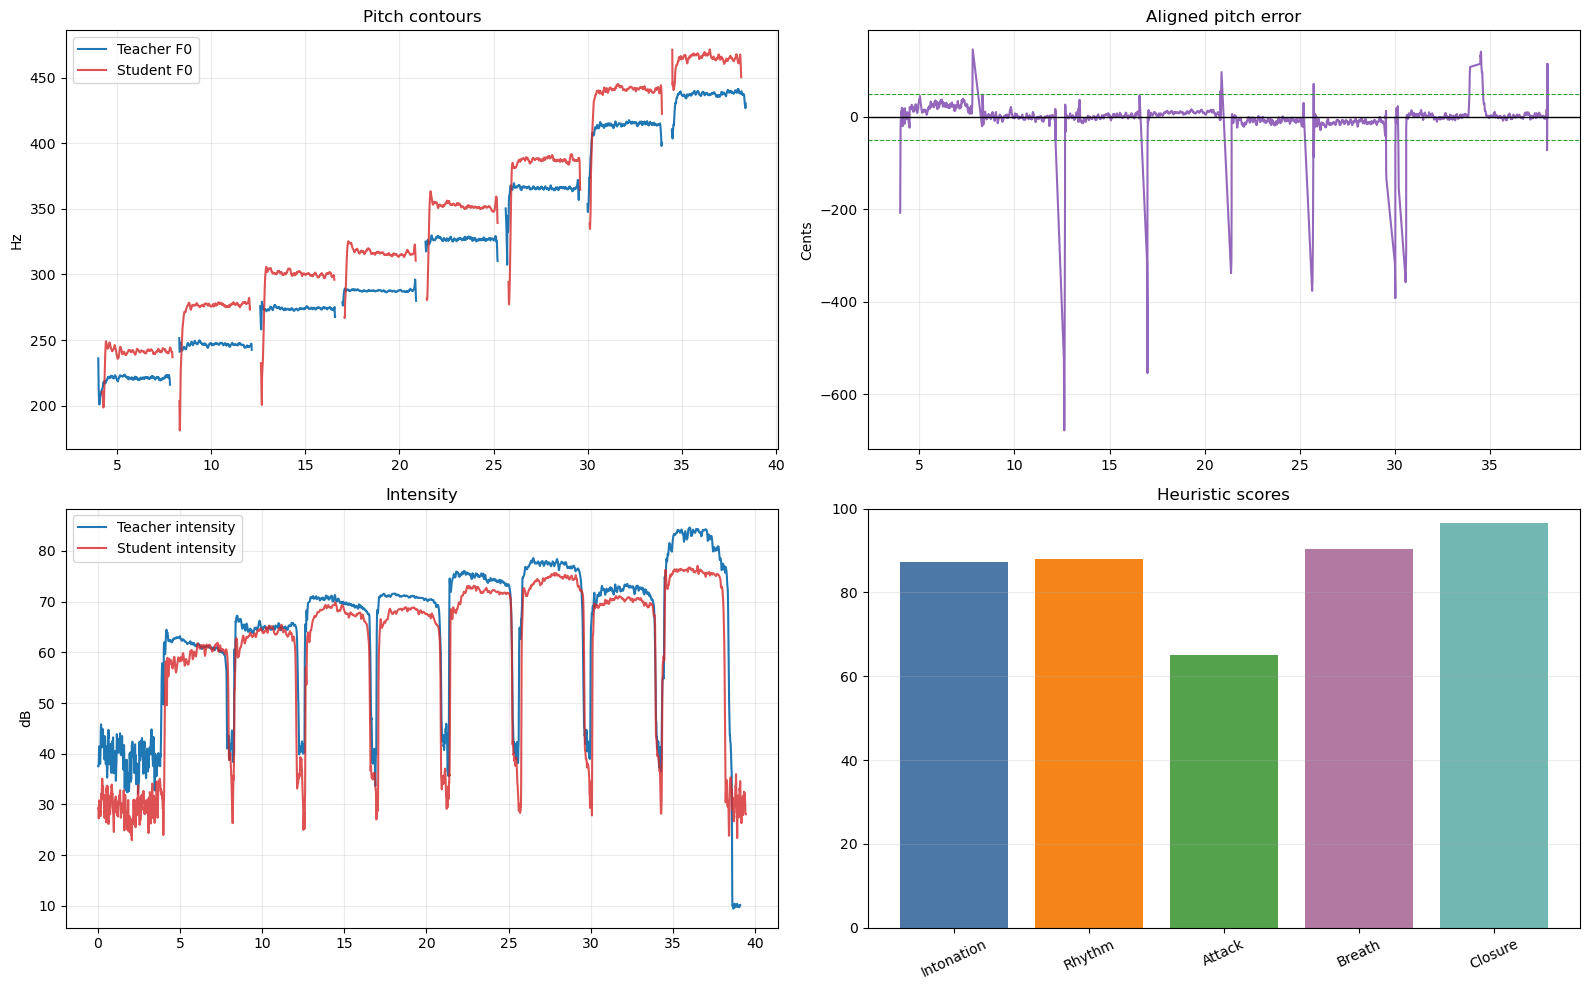

Saved report: /home/evgeniy/Projects/VocalAssistant/PraatAnalysis/reports/20220330100654__vs__20220407120212__07c4d322e3.txt
Saved metrics: /home/evgeniy/Projects/VocalAssistant/PraatAnalysis/reports/20220330100654__vs__20220407120212__07c4d322e3.json
Saved plot: /home/evgeniy/Projects/VocalAssistant/PraatAnalysis/reports/20220330100654__vs__20220407120212__07c4d322e3.png


In [21]:
feedback_text = globals().get('feedback_text', None)
pair_key = f'{TEACHER_AUDIO.resolve()}||{STUDENT_AUDIO.resolve()}'
pair_hash = hashlib.sha1(pair_key.encode('utf-8')).hexdigest()[:10]
base_name = f'{TEACHER_AUDIO.stem}__vs__{STUDENT_AUDIO.stem}__{pair_hash}'

report_path = OUTPUT_DIR / f'{base_name}.txt'
json_path = OUTPUT_DIR / f'{base_name}.json'
plot_path = OUTPUT_DIR / f'{base_name}.png'
feedback_path = OUTPUT_DIR / f'{base_name}__feedback.md'

report_path.write_text(report_text + '\n', encoding='utf-8')

json_ready = {
    'teacher_audio': str(TEACHER_AUDIO),
    'student_audio': str(STUDENT_AUDIO),
    'metrics': {k: (None if not np.isfinite(v) else float(v)) if isinstance(v, (float, np.floating)) else v for k, v in metrics.items()},
    'priority_flags': build_recommendation_flags(metrics),
}
json_path.write_text(json.dumps(json_ready, ensure_ascii=False, indent=2), encoding='utf-8')

if feedback_text:
    feedback_path.write_text(feedback_text + '\n', encoding='utf-8')

fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(2, 2)
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 0])
ax4 = fig.add_subplot(gs[1, 1])

ax1.plot(teacher['time'], teacher['f0'], label='Teacher F0', color='tab:blue')
ax1.plot(student['time'], student['f0'], label='Student F0', color='tab:red', alpha=0.8)
ax1.set_title('Pitch contours')
ax1.set_ylabel('Hz')
ax1.grid(alpha=0.25)
ax1.legend()

if len(errors):
    ax2.plot(teacher['time'][alignment['teacher_idx']], errors, color='tab:purple')
    ax2.axhline(0, color='black', linewidth=1)
    ax2.axhline(50, color='tab:green', linestyle='--', linewidth=0.8)
    ax2.axhline(-50, color='tab:green', linestyle='--', linewidth=0.8)
ax2.set_title('Aligned pitch error')
ax2.set_ylabel('Cents')
ax2.grid(alpha=0.25)

ax3.plot(teacher['time'], teacher['intensity'], label='Teacher intensity', color='tab:blue')
ax3.plot(student['time'], student['intensity'], label='Student intensity', color='tab:red', alpha=0.8)
ax3.set_title('Intensity')
ax3.set_ylabel('dB')
ax3.grid(alpha=0.25)
ax3.legend()

score_labels = ['Intonation', 'Rhythm', 'Attack', 'Breath', 'Closure']
score_values = [metrics['intonation_score'], metrics['rhythm_score'], metrics['attack_score'], metrics['breath_score'], metrics['voice_closure_score']]
ax4.bar(score_labels, score_values, color=['#4C78A8', '#F58518', '#54A24B', '#B279A2', '#72B7B2', '#E45756'])
ax4.set_ylim(0, 100)
ax4.set_title('Heuristic scores')
ax4.tick_params(axis='x', rotation=25)
ax4.grid(axis='y', alpha=0.25)

plt.tight_layout()
fig.savefig(plot_path, dpi=160)
plt.show()

print('Saved report:', report_path)
print('Saved metrics:', json_path)
print('Saved plot:', plot_path)
if feedback_text:
    print('Saved feedback:', feedback_path)
